In [0]:
# EDA 
import matplotlib.pyplot as plt
from pyspark.sql.types import StructType, StructField, StringType, IntegerType
from pyspark.sql.functions import concat, lit

flight_schema = StructType([
    StructField("flight_id", StringType(), True),
    StructField("airline", StringType(), True),
    StructField("from_city", StringType(), True),
    StructField("to_city", StringType(), True),
    StructField("duration", IntegerType(), True),
    StructField("status", StringType(), True)
])

booking_schema = StructType([
    StructField("booking_id", StringType(), True),
    StructField("flight_id", StringType(), True),
    StructField("passenger_name", StringType(), True),
    StructField("travel_class", StringType(), True),
    StructField("ticket_price", IntegerType(), True),
    StructField("booking_date", StringType(), True)
])

In [0]:
flights_data = [
    ("F101", "Indigo", "Hyderabad", "Delhi", 140, "On Time"),
    ("F102", "Air India", "Mumbai", "Chennai", 120, "Delayed"),
    ("F103", "Vistara", "Bangalore", "Hyderabad", 90, "On Time"),
    ("F104", "Indigo", "Delhi", "Mumbai", 130, "Cancelled"),
    ("F105", "Air India", "Chennai", "Bangalore", 80, "On Time"),
    ("F106", "Akasa", "Pune", "Delhi", 150, "Delayed"),
    ("F107", "Vistara", "Hyderabad", "Kolkata", 160, "On Time"),
    ("F108", "Indigo", "Mumbai", "Hyderabad", 110, "On Time"),
    ("F109", "Akasa", "Delhi", "Chennai", 145, "Delayed"),
    ("F110", "Air India", "Bangalore", "Mumbai", 95, "On Time"),
    ("F111", "Indigo", "Hyderabad", "Goa", 75, "On Time"),
    ("F112", "Vistara", "Goa", "Delhi", 150, "Cancelled"),
    ("F113", "Akasa", "Chennai", "Pune", 100, "On Time"),
    ("F114", "Air India", "Kolkata", "Bangalore", 170, "Delayed"),
    ("F115", "Indigo", "Delhi", "Hyderabad", 135, "On Time"),
]

bookings_data = [
    ("B1001", "F101", "Rahul Sharma", "Economy", 8500, "2026-06-01"),
    ("B1002", "F101", "Priya Reddy", "Business", 22000, "2026-06-01"),
    ("B1003", "F102", "Amit Kumar", "Economy", 9000, "2026-06-02"),
    ("B1004", "F103", "Sneha Patel", "Premium Economy", 15000, "2026-06-02"),
    ("B1005", "F104", "Farhan Ali", "Economy", 7500, "2026-06-03"),
    ("B1006", "F105", "Neha Singh", "Business", 25000, "2026-06-03"),
    ("B1007", "F106", "Arjun Verma", "Economy", 10000, "2026-06-04"),
    ("B1008", "F107", "Meera Nair", "Premium Economy", 17000, "2026-06-04"),
    ("B1009", "F108", "Kiran Rao", "Economy", 9500, "2026-06-05"),
    ("B1010", "F109", "Nisha Reddy", "Business", 28000, "2026-06-05"),
    ("B1011", "F110", "David Thomas", "Economy", 8000, "2026-06-06"),
    ("B1012", "F111", "Ayesha Khan", "Premium Economy", 16000, "2026-06-06"),
    ("B1013", "F112", "Rohit Sharma", "Economy", 7000, "2026-06-07"),
    ("B1014", "F113", "Pooja Mehta", "Business", 24000, "2026-06-07"),
    ("B1015", "F114", "Sanjay Gupta", "Economy", 10500, "2026-06-08"),
    ("B1016", "F115", "Divya Iyer", "Premium Economy", 18000, "2026-06-08"),
    ("B1017", "F101", "Rahul Sharma", "Economy", 8500, "2026-06-09"),
    ("B1018", "F103", "Priya Reddy", "Business", 23000, "2026-06-09"),
    ("B1019", "F107", "Amit Kumar", "Economy", 9500, "2026-06-10"),
    ("B1020", "F110", "Sneha Patel", "Premium Economy", 15500, "2026-06-10"),
]

df_flights = spark.createDataFrame(flights_data, flight_schema)
df_bookings = spark.createDataFrame(bookings_data, booking_schema)
df_joined = df_bookings.join(df_flights, on="flight_id", how="left")

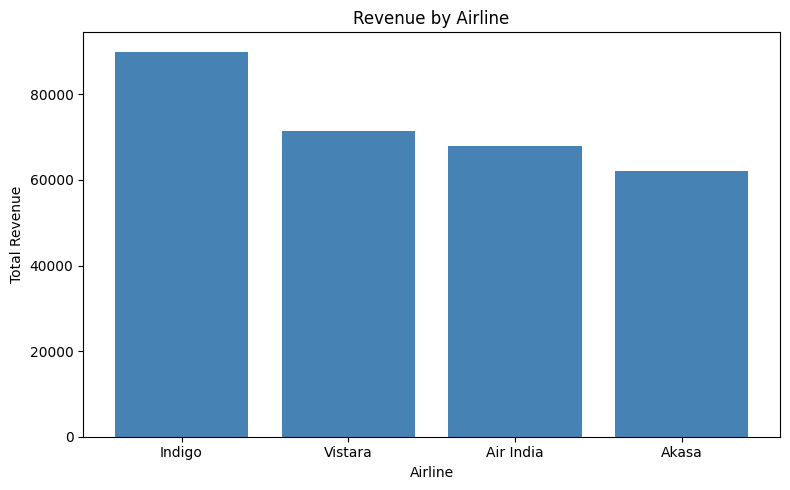

In [0]:
revenue_airline = df_joined.groupBy("airline").sum("ticket_price").toPandas()
revenue_airline.columns = ["airline", "total_revenue"]
revenue_airline = revenue_airline.sort_values("total_revenue", ascending=False)

plt.figure(figsize=(8,5))
plt.bar(revenue_airline["airline"], revenue_airline["total_revenue"], color="steelblue")
plt.title("Revenue by Airline")
plt.xlabel("Airline")
plt.ylabel("Total Revenue")
plt.tight_layout()
plt.show()

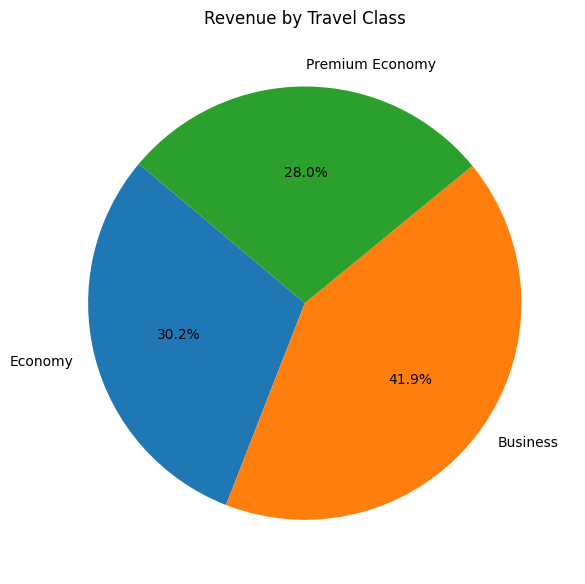

In [0]:
revenue_class = df_bookings.groupBy("travel_class").sum("ticket_price").toPandas()
revenue_class.columns = ["travel_class", "total_revenue"]

plt.figure(figsize=(6,6))
plt.pie(revenue_class["total_revenue"], labels=revenue_class["travel_class"], autopct="%1.1f%%", startangle=140)
plt.title("Revenue by Travel Class")
plt.tight_layout()
plt.show()

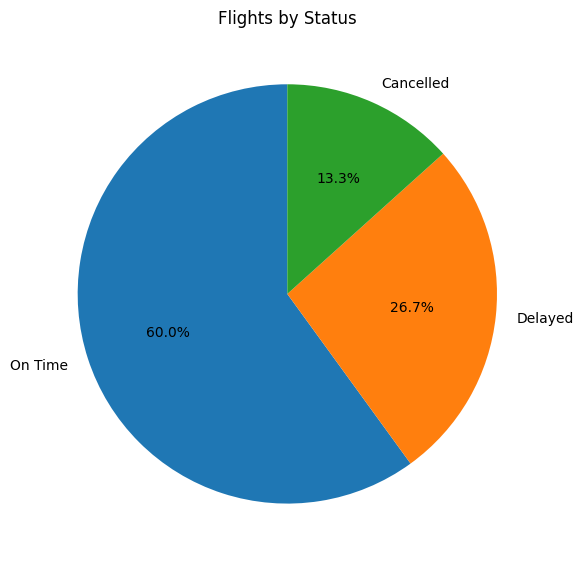

In [0]:
status_count = df_flights.groupBy("status").count().toPandas()

plt.figure(figsize=(6,6))
plt.pie(status_count["count"], labels=status_count["status"], autopct="%1.1f%%", startangle=90)
plt.title("Flights by Status")
plt.tight_layout()
plt.show()

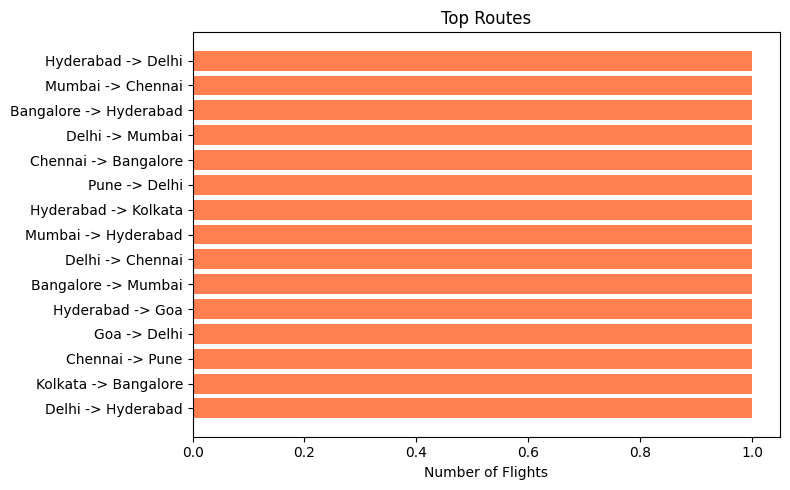

In [0]:
df_routes = df_flights.withColumn("route", concat(df_flights["from_city"], lit(" -> "), df_flights["to_city"]))
top_routes = df_routes.groupBy("route").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(8,5))
plt.barh(top_routes["route"], top_routes["count"], color="coral")
plt.title("Top Routes")
plt.xlabel("Number of Flights")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

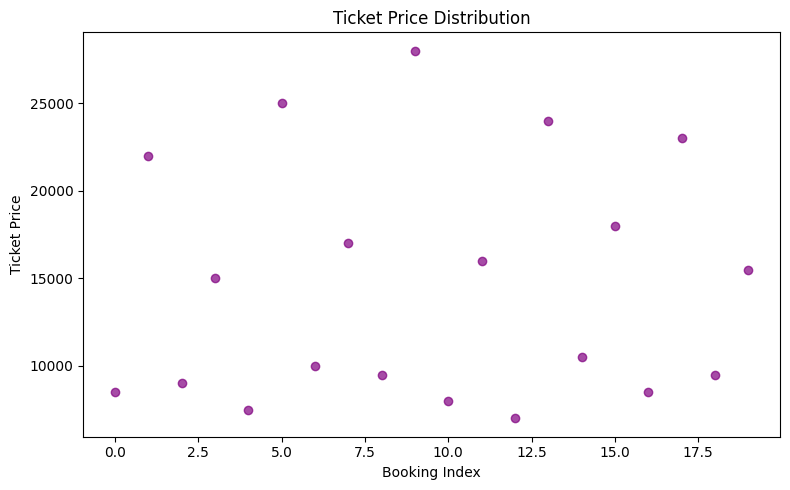

In [0]:
price_df = df_bookings.select("booking_id", "ticket_price").toPandas()

plt.figure(figsize=(8,5))
plt.scatter(range(len(price_df)), price_df["ticket_price"], color="purple", alpha=0.7)
plt.title("Ticket Price Distribution")
plt.xlabel("Booking Index")
plt.ylabel("Ticket Price")
plt.tight_layout()
plt.show()

In [0]:
# Transformations

from pyspark.sql.functions import col, when

df_transformed = df_joined.withColumn("revenue", col("ticket_price")) \
    .withColumn("price_band",
        when(col("ticket_price") > 20000, "Premium")
        .when(col("ticket_price") > 10000, "Standard")
        .otherwise("Budget")
    ) \
    .withColumn("delay_flag",
        when(col("status") == "Delayed", "Yes")
        .otherwise("No")
    )

In [0]:
display(df_transformed.select("booking_id", "passenger_name", "ticket_price", "revenue", "price_band", "status", "delay_flag"))

booking_id,passenger_name,ticket_price,revenue,price_band,status,delay_flag
B1001,Rahul Sharma,8500,8500,Budget,On Time,No
B1002,Priya Reddy,22000,22000,Premium,On Time,No
B1003,Amit Kumar,9000,9000,Budget,Delayed,Yes
B1004,Sneha Patel,15000,15000,Standard,On Time,No
B1005,Farhan Ali,7500,7500,Budget,Cancelled,No
B1006,Neha Singh,25000,25000,Premium,On Time,No
B1007,Arjun Verma,10000,10000,Budget,Delayed,Yes
B1008,Meera Nair,17000,17000,Standard,On Time,No
B1009,Kiran Rao,9500,9500,Budget,On Time,No
B1010,Nisha Reddy,28000,28000,Premium,Delayed,Yes


In [0]:
# Joins

from pyspark.sql.types import BooleanType

pref_schema = StructType([
    StructField("passenger_name", StringType(), True),
    StructField("meal", StringType(), True),
    StructField("seat", StringType(), True),
    StructField("extra_baggage", BooleanType(), True)
])

prefs_data = [
    ("Rahul Sharma", "Veg", "Window", True),
    ("Priya Reddy", "Non-Veg", "Aisle", False),
    ("Amit Kumar", "Veg", "Middle", False),
    ("Sneha Patel", "Jain", "Window", True),
    ("Farhan Ali", "Non-Veg", "Aisle", False),
    ("Neha Singh", "Veg", "Window", True),
    ("Arjun Verma", "Veg", "Middle", False),
    ("Meera Nair", "Jain", "Window", True),
    ("Kiran Rao", "Veg", "Aisle", False),
    ("Nisha Reddy", "Non-Veg", "Window", True),
    ("David Thomas", "Veg", "Middle", False),
    ("Ayesha Khan", "Jain", "Window", True),
    ("Rohit Sharma", "Veg", "Aisle", False),
    ("Pooja Mehta", "Non-Veg", "Window", True),
    ("Sanjay Gupta", "Veg", "Middle", False),
    ("Divya Iyer", "Jain", "Window", True),
]

df_prefs = spark.createDataFrame(prefs_data, pref_schema)

In [0]:
df_passenger_journey = df_transformed \
    .join(df_prefs, on="passenger_name", how="left")

In [0]:
display(df_passenger_journey.select(
    "booking_id",
    "passenger_name",
    "flight_id",
    "airline",
    "from_city",
    "to_city",
    "travel_class",
    "ticket_price",
    "revenue",
    "price_band",
    "status",
    "delay_flag",
    "meal",
    "seat",
    "extra_baggage",
    "booking_date"
))

booking_id,passenger_name,flight_id,airline,from_city,to_city,travel_class,ticket_price,revenue,price_band,status,delay_flag,meal,seat,extra_baggage,booking_date
B1001,Rahul Sharma,F101,Indigo,Hyderabad,Delhi,Economy,8500,8500,Budget,On Time,No,Veg,Window,true,2026-06-01
B1002,Priya Reddy,F101,Indigo,Hyderabad,Delhi,Business,22000,22000,Premium,On Time,No,Non-Veg,Aisle,false,2026-06-01
B1003,Amit Kumar,F102,Air India,Mumbai,Chennai,Economy,9000,9000,Budget,Delayed,Yes,Veg,Middle,false,2026-06-02
B1004,Sneha Patel,F103,Vistara,Bangalore,Hyderabad,Premium Economy,15000,15000,Standard,On Time,No,Jain,Window,true,2026-06-02
B1005,Farhan Ali,F104,Indigo,Delhi,Mumbai,Economy,7500,7500,Budget,Cancelled,No,Non-Veg,Aisle,false,2026-06-03
B1006,Neha Singh,F105,Air India,Chennai,Bangalore,Business,25000,25000,Premium,On Time,No,Veg,Window,true,2026-06-03
B1007,Arjun Verma,F106,Akasa,Pune,Delhi,Economy,10000,10000,Budget,Delayed,Yes,Veg,Middle,false,2026-06-04
B1008,Meera Nair,F107,Vistara,Hyderabad,Kolkata,Premium Economy,17000,17000,Standard,On Time,No,Jain,Window,true,2026-06-04
B1009,Kiran Rao,F108,Indigo,Mumbai,Hyderabad,Economy,9500,9500,Budget,On Time,No,Veg,Aisle,false,2026-06-05
B1010,Nisha Reddy,F109,Akasa,Delhi,Chennai,Business,28000,28000,Premium,Delayed,Yes,Non-Veg,Window,true,2026-06-05


In [0]:
# Spark SQL
df_passenger_journey.createOrReplaceTempView("passenger_journey")

In [0]:
spark.sql("""
    SELECT airline, SUM(revenue) AS total_revenue
    FROM passenger_journey
    GROUP BY airline
    ORDER BY total_revenue DESC
""").show()

+---------+-------------+
|  airline|total_revenue|
+---------+-------------+
|   Indigo|        90000|
|  Vistara|        71500|
|Air India|        68000|
|    Akasa|        62000|
+---------+-------------+



In [0]:
spark.sql("""
    SELECT concat(from_city, ' -> ', to_city) AS route, SUM(revenue) AS total_revenue
    FROM passenger_journey
    GROUP BY from_city, to_city
    ORDER BY total_revenue DESC
""").show()

+--------------------+-------------+
|               route|total_revenue|
+--------------------+-------------+
|  Hyderabad -> Delhi|        39000|
|Bangalore -> Hyde...|        38000|
|    Delhi -> Chennai|        28000|
|Hyderabad -> Kolkata|        26500|
|Chennai -> Bangalore|        25000|
|     Chennai -> Pune|        24000|
| Bangalore -> Mumbai|        23500|
|  Delhi -> Hyderabad|        18000|
|    Hyderabad -> Goa|        16000|
|Kolkata -> Bangalore|        10500|
|       Pune -> Delhi|        10000|
| Mumbai -> Hyderabad|         9500|
|   Mumbai -> Chennai|         9000|
|     Delhi -> Mumbai|         7500|
|        Goa -> Delhi|         7000|
+--------------------+-------------+



In [0]:
spark.sql("""
    SELECT ROUND(AVG(ticket_price), 2) AS avg_ticket_price
    FROM passenger_journey
""").show()

+----------------+
|avg_ticket_price|
+----------------+
|         14575.0|
+----------------+



In [0]:
spark.sql("""
    SELECT to_city AS destination, COUNT(*) AS total_passengers
    FROM passenger_journey
    GROUP BY to_city
    ORDER BY total_passengers DESC
    LIMIT 5
""").show()

+-----------+----------------+
|destination|total_passengers|
+-----------+----------------+
|      Delhi|               5|
|  Hyderabad|               4|
|     Mumbai|               3|
|    Chennai|               2|
|  Bangalore|               2|
+-----------+----------------+



In [0]:
# Window Functions

from pyspark.sql.functions import rank, dense_rank, sum, row_number
from pyspark.sql.window import Window

In [0]:
window_flight = Window.orderBy(col("revenue").desc())
df_top_flights = df_passenger_journey.withColumn("flight_rank", row_number().over(window_flight))
display(df_top_flights.filter(col("flight_rank") <= 3).select("flight_id", "airline", "from_city", "to_city", "revenue", "flight_rank"))

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


flight_id,airline,from_city,to_city,revenue,flight_rank
F109,Akasa,Delhi,Chennai,28000,1
F105,Air India,Chennai,Bangalore,25000,2
F113,Akasa,Chennai,Pune,24000,3


In [0]:
window_airline_route = Window.partitionBy("airline").orderBy(col("revenue").desc())
df_top_routes = df_passenger_journey.withColumn("route_rank", row_number().over(window_airline_route))
display(df_top_routes.filter(col("route_rank") == 1).select("airline", "from_city", "to_city", "revenue", "route_rank"))

airline,from_city,to_city,revenue,route_rank
Air India,Chennai,Bangalore,25000,1
Akasa,Delhi,Chennai,28000,1
Indigo,Hyderabad,Delhi,22000,1
Vistara,Bangalore,Hyderabad,23000,1


In [0]:
window_running = Window.partitionBy("airline").orderBy("booking_date").rowsBetween(Window.unboundedPreceding, Window.currentRow)
df_running_revenue = df_passenger_journey.withColumn("running_revenue", sum(col("revenue")).over(window_running))
display(df_running_revenue.select("airline", "booking_date", "revenue", "running_revenue"))

airline,booking_date,revenue,running_revenue
Air India,2026-06-02,9000,9000
Air India,2026-06-03,25000,34000
Air India,2026-06-06,8000,42000
Air India,2026-06-08,10500,52500
Air India,2026-06-10,15500,68000
Akasa,2026-06-04,10000,10000
Akasa,2026-06-05,28000,38000
Akasa,2026-06-07,24000,62000
Indigo,2026-06-01,8500,8500
Indigo,2026-06-01,22000,30500


In [0]:
window_rank = Window.orderBy(col("total_revenue").desc())
df_airline_revenue = df_passenger_journey.groupBy("airline").agg(sum("revenue").alias("total_revenue"))
df_airline_ranked = df_airline_revenue.withColumn("rank", rank().over(window_rank))
display(df_airline_ranked)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


airline,total_revenue,rank
Indigo,90000,1
Vistara,71500,2
Air India,68000,3
Akasa,62000,4


In [0]:
window_dense = Window.orderBy(col("total_passengers").desc())
df_dest = df_passenger_journey.groupBy("to_city").count().withColumnRenamed("count", "total_passengers")
df_dest_ranked = df_dest.withColumn("dense_rank", dense_rank().over(window_dense))
display(df_dest_ranked)

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1160: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


to_city,total_passengers,dense_rank
Delhi,5,1
Hyderabad,4,2
Mumbai,3,3
Chennai,2,4
Bangalore,2,4
Kolkata,2,4
Goa,1,5
Pune,1,5


In [0]:
from pyspark.sql.types import StructType, StructField, StringType, IntegerType

booking_schema = StructType([
    StructField("booking_id", StringType(), True),
    StructField("flight_id", StringType(), True),
    StructField("passenger_name", StringType(), True),
    StructField("travel_class", StringType(), True),
    StructField("ticket_price", IntegerType(), True),
    StructField("booking_date", StringType(), True)
])

day1_data = [
    ("B1001", "F101", "Rahul Sharma", "Economy", 8500, "2026-06-01"),
    ("B1002", "F101", "Priya Reddy", "Business", 22000, "2026-06-01"),
    ("B1003", "F102", "Amit Kumar", "Economy", 9000, "2026-06-02"),
    ("B1004", "F103", "Sneha Patel", "Premium Economy", 15000, "2026-06-02"),
    ("B1005", "F104", "Farhan Ali", "Economy", 7500, "2026-06-03"),
    ("B1006", "F105", "Neha Singh", "Business", 25000, "2026-06-03"),
    ("B1007", "F106", "Arjun Verma", "Economy", 10000, "2026-06-04"),
    ("B1008", "F107", "Meera Nair", "Premium Economy", 17000, "2026-06-04"),
    ("B1009", "F108", "Kiran Rao", "Economy", 9500, "2026-06-05"),
    ("B1010", "F109", "Nisha Reddy", "Business", 28000, "2026-06-05"),
    ("B1011", "F110", "David Thomas", "Economy", 8000, "2026-06-06"),
    ("B1012", "F111", "Ayesha Khan", "Premium Economy", 16000, "2026-06-06"),
    ("B1013", "F112", "Rohit Sharma", "Economy", 7000, "2026-06-07"),
    ("B1014", "F113", "Pooja Mehta", "Business", 24000, "2026-06-07"),
    ("B1015", "F114", "Sanjay Gupta", "Economy", 10500, "2026-06-08"),
    ("B1016", "F115", "Divya Iyer", "Premium Economy", 18000, "2026-06-08"),
    ("B1017", "F101", "Rahul Sharma", "Economy", 8500, "2026-06-09"),
    ("B1018", "F103", "Priya Reddy", "Business", 23000, "2026-06-09"),
    ("B1019", "F107", "Amit Kumar", "Economy", 9500, "2026-06-10"),
    ("B1020", "F110", "Sneha Patel", "Premium Economy", 15500, "2026-06-10"),
]

df_day1 = spark.createDataFrame(day1_data, booking_schema)
df_day1.createOrReplaceTempView("bookings_day1")
display(df_day1)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
day2_new = [
    ("B1021", "F101", "Karan Johar", "Economy", 8500, "2026-06-11"),
    ("B1022", "F102", "Simran Kaur", "Business", 22000, "2026-06-11"),
    ("B1023", "F103", "Ravi Teja", "Economy", 9000, "2026-06-12"),
    ("B1024", "F104", "Ananya Das", "Premium Economy", 15000, "2026-06-12"),
    ("B1025", "F105", "Vikram Nair", "Economy", 7500, "2026-06-13"),
    ("B1026", "F106", "Pallavi Rao", "Business", 25000, "2026-06-13"),
    ("B1027", "F107", "Suresh Kumar", "Economy", 10000, "2026-06-14"),
    ("B1028", "F108", "Kavya Reddy", "Premium Economy", 17000, "2026-06-14"),
    ("B1029", "F109", "Manoj Singh", "Economy", 9500, "2026-06-15"),
    ("B1030", "F110", "Deepa Iyer", "Business", 28000, "2026-06-15"),
]

day2_updates = [
    ("B1001", "F101", "Rahul Sharma", "Economy", 9500, "2026-06-01"),
    ("B1002", "F101", "Priya Reddy", "Business", 24000, "2026-06-01"),
    ("B1003", "F102", "Amit Kumar", "Economy", 9800, "2026-06-02"),
    ("B1004", "F103", "Sneha Patel", "Premium Economy", 16000, "2026-06-02"),
    ("B1005", "F104", "Farhan Ali", "Economy", 8200, "2026-06-03"),
]

df_day2 = spark.createDataFrame(day2_new + day2_updates, booking_schema)
df_day2.createOrReplaceTempView("bookings_day2")
display(df_day2)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1021,F101,Karan Johar,Economy,8500,2026-06-11
B1022,F102,Simran Kaur,Business,22000,2026-06-11
B1023,F103,Ravi Teja,Economy,9000,2026-06-12
B1024,F104,Ananya Das,Premium Economy,15000,2026-06-12
B1025,F105,Vikram Nair,Economy,7500,2026-06-13
B1026,F106,Pallavi Rao,Business,25000,2026-06-13
B1027,F107,Suresh Kumar,Economy,10000,2026-06-14
B1028,F108,Kavya Reddy,Premium Economy,17000,2026-06-14
B1029,F109,Manoj Singh,Economy,9500,2026-06-15
B1030,F110,Deepa Iyer,Business,28000,2026-06-15


In [0]:
from pyspark.sql.functions import broadcast

df_merged = df_day1.alias("target").join(df_day2.alias("source"), on="booking_id", how="full_outer") \
    .selectExpr(
        "coalesce(source.booking_id, target.booking_id) as booking_id",
        "coalesce(source.flight_id, target.flight_id) as flight_id",
        "coalesce(source.passenger_name, target.passenger_name) as passenger_name",
        "coalesce(source.travel_class, target.travel_class) as travel_class",
        "coalesce(source.ticket_price, target.ticket_price) as ticket_price",
        "coalesce(source.booking_date, target.booking_date) as booking_date"
    )

display(df_merged.orderBy("booking_id"))

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,9500,2026-06-01
B1002,F101,Priya Reddy,Business,24000,2026-06-01
B1003,F102,Amit Kumar,Economy,9800,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,16000,2026-06-02
B1005,F104,Farhan Ali,Economy,8200,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
# Time Travel

df_version0 = df_day1
df_version0.createOrReplaceTempView("version0")
display(df_version0)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,8500,2026-06-01
B1002,F101,Priya Reddy,Business,22000,2026-06-01
B1003,F102,Amit Kumar,Economy,9000,2026-06-02
B1004,F103,Sneha Patel,Premium Economy,15000,2026-06-02
B1005,F104,Farhan Ali,Economy,7500,2026-06-03
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1009,F108,Kiran Rao,Economy,9500,2026-06-05
B1010,F109,Nisha Reddy,Business,28000,2026-06-05


In [0]:
df_version1 = df_day2
df_version1.createOrReplaceTempView("version1")
display(df_version1)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1021,F101,Karan Johar,Economy,8500,2026-06-11
B1022,F102,Simran Kaur,Business,22000,2026-06-11
B1023,F103,Ravi Teja,Economy,9000,2026-06-12
B1024,F104,Ananya Das,Premium Economy,15000,2026-06-12
B1025,F105,Vikram Nair,Economy,7500,2026-06-13
B1026,F106,Pallavi Rao,Business,25000,2026-06-13
B1027,F107,Suresh Kumar,Economy,10000,2026-06-14
B1028,F108,Kavya Reddy,Premium Economy,17000,2026-06-14
B1029,F109,Manoj Singh,Economy,9500,2026-06-15
B1030,F110,Deepa Iyer,Business,28000,2026-06-15


In [0]:
df_latest = df_merged
df_latest.createOrReplaceTempView("latest_version")
display(df_latest)

booking_id,flight_id,passenger_name,travel_class,ticket_price,booking_date
B1001,F101,Rahul Sharma,Economy,9500,2026-06-01
B1002,F101,Priya Reddy,Business,24000,2026-06-01
B1003,F102,Amit Kumar,Economy,9800,2026-06-02
B1005,F104,Farhan Ali,Economy,8200,2026-06-03
B1004,F103,Sneha Patel,Premium Economy,16000,2026-06-02
B1007,F106,Arjun Verma,Economy,10000,2026-06-04
B1006,F105,Neha Singh,Business,25000,2026-06-03
B1008,F107,Meera Nair,Premium Economy,17000,2026-06-04
B1010,F109,Nisha Reddy,Business,28000,2026-06-05
B1009,F108,Kiran Rao,Economy,9500,2026-06-05


In [0]:
print("Version 0 - Before Merge - Total Bookings:", df_version0.count())
print("Version 1 - New + Updated Bookings:", df_version1.count())
print("Latest - After Merge - Total Bookings:", df_latest.count())

Version 0 - Before Merge - Total Bookings: 20
Version 1 - New + Updated Bookings: 15
Latest - After Merge - Total Bookings: 30


In [0]:
df_before = spark.sql("SELECT * FROM version0")
df_after = spark.sql("SELECT * FROM latest_version")

df_compare = df_before.alias("before").join(df_after.alias("after"), on="booking_id", how="outer") \
    .selectExpr(
        "coalesce(before.booking_id, after.booking_id) as booking_id",
        "before.ticket_price as price_before_merge",
        "after.ticket_price as price_after_merge",
        "case when before.ticket_price != after.ticket_price then 'Updated' when before.booking_id is null then 'New' else 'Unchanged' end as status"
    )

display(df_compare.orderBy("booking_id"))

booking_id,price_before_merge,price_after_merge,status
B1001,8500,9500,Updated
B1002,22000,24000,Updated
B1003,9000,9800,Updated
B1004,15000,16000,Updated
B1005,7500,8200,Updated
B1006,25000,25000,Unchanged
B1007,10000,10000,Unchanged
B1008,17000,17000,Unchanged
B1009,9500,9500,Unchanged
B1010,28000,28000,Unchanged


In [0]:
# optimize delta
df_merged.createOrReplaceTempView("booking_master")

In [0]:
# OPTIMIZE compacts small files into larger ones for better performance
# spark.sql("OPTIMIZE capstone.bronze.booking_master")
print("OPTIMIZE - Compacts small Delta files into larger files for faster reads")

OPTIMIZE - Compacts small Delta files into larger files for faster reads


In [0]:
# ZORDER co-locates related data in same files for faster filtering
# spark.sql("OPTIMIZE capstone.bronze.booking_master ZORDER BY (flight_id)")
print("ZORDER BY flight_id - Co-locates data by flight_id for faster queries on flight_id column")

ZORDER BY flight_id - Co-locates data by flight_id for faster queries on flight_id column


In [0]:
# VACUUM removes old files older than 7 days (default retention)
# spark.sql("VACUUM capstone.bronze.booking_master")
print("VACUUM - Removes old unused Delta files older than 7 days retention period")

VACUUM - Removes old unused Delta files older than 7 days retention period


In [0]:
# DESCRIBE HISTORY shows all versions of the Delta table
# spark.sql("DESCRIBE HISTORY capstone.bronze.booking_master").show(truncate=False)
print("DESCRIBE HISTORY - Shows all versions, timestamps and operations performed on Delta table")

DESCRIBE HISTORY - Shows all versions, timestamps and operations performed on Delta table


In [0]:
# Tables and Views
spark.sql("""
    CREATE OR REPLACE TEMP VIEW booking_external
    AS SELECT * FROM booking_master
""")
spark.sql("SELECT * FROM booking_external").show()


+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        9500|  2026-06-01|
|     B1002|     F101|   Priya Reddy|       Business|       24000|  2026-06-01|
|     B1003|     F102|    Amit Kumar|        Economy|        9800|  2026-06-02|
|     B1005|     F104|    Farhan Ali|        Economy|        8200|  2026-06-03|
|     B1004|     F103|   Sneha Patel|Premium Economy|       16000|  2026-06-02|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|
|     B1008|     F107|    Meera Nair|Premium Economy|       17000|  2026-06-04|
|     B1010|     F109|   Nisha Reddy|       Business|       28000|  2026-06-05|
|     B1009|     F108|     Kiran Rao|   

In [0]:
df_merged.createOrReplaceTempView("booking_temp_view")
spark.sql("SELECT * FROM booking_temp_view").show()

+----------+---------+--------------+---------------+------------+------------+
|booking_id|flight_id|passenger_name|   travel_class|ticket_price|booking_date|
+----------+---------+--------------+---------------+------------+------------+
|     B1001|     F101|  Rahul Sharma|        Economy|        9500|  2026-06-01|
|     B1002|     F101|   Priya Reddy|       Business|       24000|  2026-06-01|
|     B1003|     F102|    Amit Kumar|        Economy|        9800|  2026-06-02|
|     B1005|     F104|    Farhan Ali|        Economy|        8200|  2026-06-03|
|     B1004|     F103|   Sneha Patel|Premium Economy|       16000|  2026-06-02|
|     B1007|     F106|   Arjun Verma|        Economy|       10000|  2026-06-04|
|     B1006|     F105|    Neha Singh|       Business|       25000|  2026-06-03|
|     B1008|     F107|    Meera Nair|Premium Economy|       17000|  2026-06-04|
|     B1010|     F109|   Nisha Reddy|       Business|       28000|  2026-06-05|
|     B1009|     F108|     Kiran Rao|   

In [0]:
df_merged.createOrReplaceGlobalTempView("booking_global_view")
spark.sql("SELECT * FROM global_temp.booking_global_view").show()

---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-5654173718196570>, line 1
----> 1 df_merged.createOrReplaceGlobalTempView("booking_global_view")
      2 spark.sql("SELECT * FROM global_temp.booking_global_view").show()

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/dataframe.py:2129, in DataFrame.createOrReplaceGlobalTempView(self, name)
   2125 def createOrReplaceGlobalTempView(self, name: str) -> None:
   2126     command = plan.CreateView(
   2127         child=self._plan, name=name, is_global=True, replace=True
   2128     ).command(session=self._session.client)
-> 2129     _, _, ei = self._session.client.execute_command(command, self._plan.observations)
   2130     self._execution_info = ei

File /databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/client/core.py:1538, in SparkConnectClient.execute_command(self, command, ob